# Chapter 3: Evaluating Time Series

In [1]:
import pandas as pd
from Utilities.PathUtilities import *

# Data wrangling
path = get_current_working_directory().parent / 'Data' / 'M5_t20_ABC.csv'
path

WindowsPath('C:/Users/brend/Desktop/GitHub/TimeSeriesWithPyTorch/src/Data/M5_t20_ABC.csv')

In [2]:
panel_df = pd.read_csv(path, index_col=False).drop(columns ='Unnamed: 0')
panel_df['date'] = pd.to_datetime(panel_df['date'])
panel_df.set_index('date')
panel_df.head(n=10)

,id,item_id,dept_id,cat_id,state_id,sold,date,sell_price,count,ABC_class
0,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,39,2011-01-29,2.98,1969,A
1,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,65,2011-01-30,2.98,1969,A
2,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,32,2011-01-31,2.98,1969,A
3,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,44,2011-02-01,2.98,1969,A
4,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,46,2011-02-02,2.98,1969,A
5,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,61,2011-02-03,2.98,1969,A
6,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,46,2011-02-04,2.98,1969,A
7,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,58,2011-02-05,2.98,1969,A
8,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,42,2011-02-06,2.98,1969,A
9,FOODS_2_197_CA_3_evaluation,FOODS_2_197,FOODS_2,FOODS,CA,54,2011-02-07,2.98,1969,A


In [3]:
def remove_tail(df, drop_value=28):
    assert 'item_id' in df.columns and 'date' in df.columns

    # Sort to ensure chronological order per item
    df_sorted = df.sort_values(['item_id', 'date'])

    # .head(-N) returns all rows except the last N rows for each group
    df_filter = df_sorted.groupby('item_id').head(-drop_value).reset_index(drop=True)

    return df_filter

panel_df = remove_tail(panel_df, drop_value=28).copy()

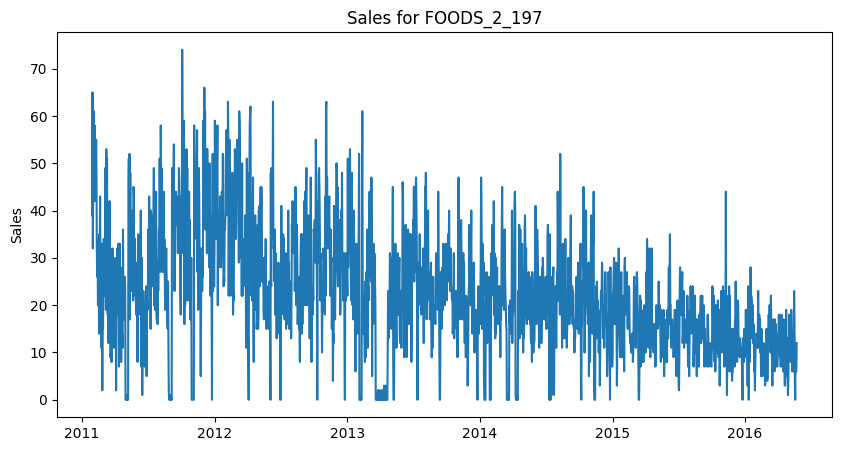

In [4]:
from matplotlib import pyplot as plt

# Single product series
series_df = panel_df.loc[panel_df.item_id == 'FOODS_2_197'].copy()
series_df['date'] = pd.to_datetime(series_df['date'])

plt.figure(figsize=(10, 5))
plt.plot(series_df['date'], series_df['sold'],)

plt.title('Sales for FOODS_2_197')
plt.ylabel("Sales")
plt.show()

We can see that the series has a complex pattern, with an obvious downward trend and strong seasonal patterns, although these are difficult to make out at this level. We can also observe quite a bit of volatility. Building on the previous chapter, we will now take a closer look at our data to better understand its structure.

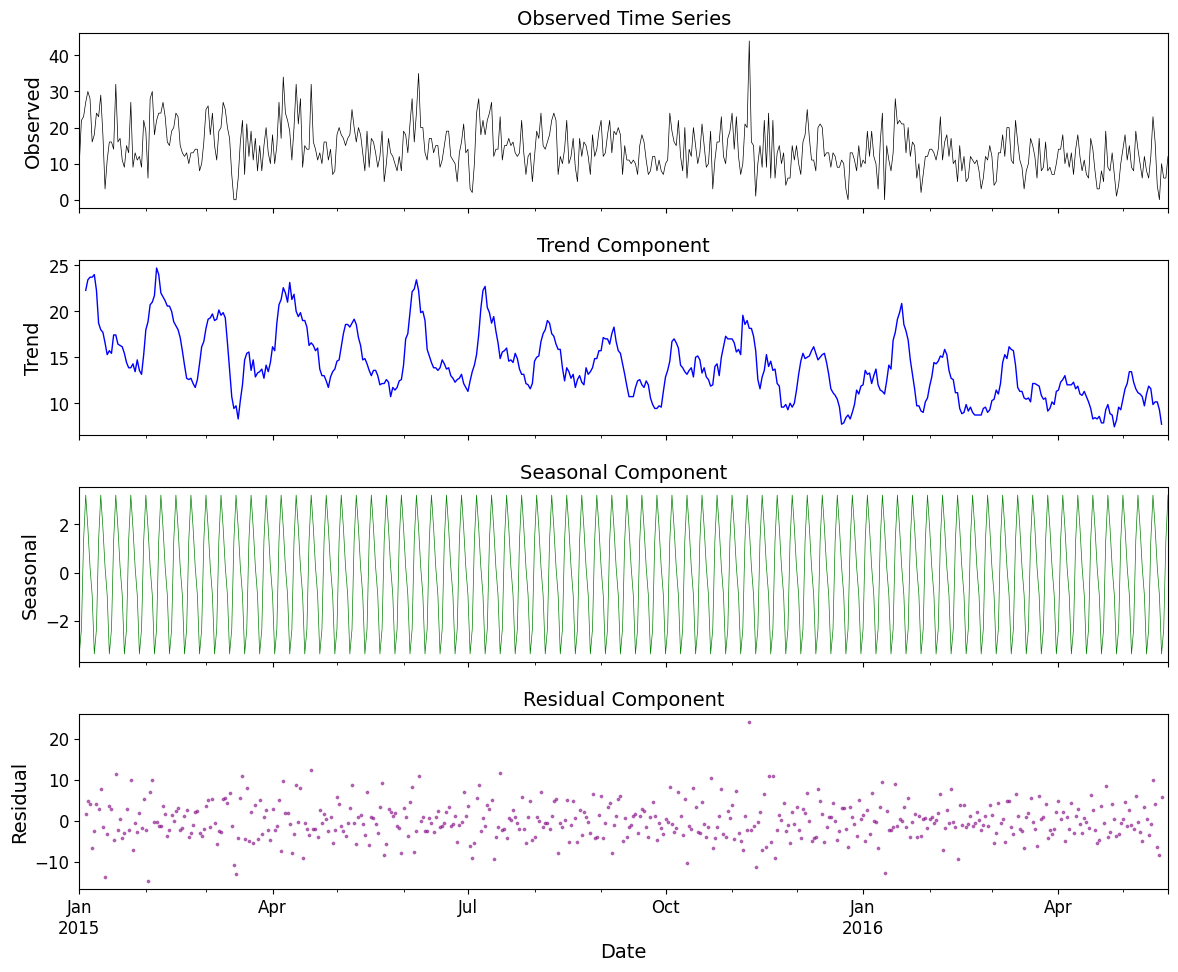

In [5]:
from Utilities.Charting import plot_seasonal_decompose
from Utilities.ColorUtilities import custom_palette
from Utilities.DataFrameUtilities import dataframe_set_index

dataframe_set_index(series_df, 'date')
short_series = series_df['2015':'2016'].copy()
fig = plot_seasonal_decompose(short_series['sold'], model='additive', custom_palette=custom_palette)
plt.show()

As we saw in the series plot (Figure 3.3), the decomposed sales slowly trend down, and there is a strong seasonal component, with both weekly and monthly variation. What is interesting is that despite the obvious negative trend seen in Figures 3.3 and 3.4, an Augmented Dickey-Fuller (ADF) test, conducted next, finds the series to be stationary on both the full and shortened series:

In [6]:
from Modeling.StatisticalModeling.StationarityTesting import adfuller_stationarity_test
adfuller_stationarity_test(series_df['sold'])

ADF Statistic: -3.606685
p-value: 0.005635
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568


Our ADF results (statistic: -3.617, p-value: 0.006) are statistically significant, with the ADF value greater than all critical values, suggesting that we should reject the non-stationarity null hypothesis. This clearly demonstrates that the ADF is a poor statistical test to rely on when you have high volatility, complex seasonal patterns, or exogenous variables with a strong impact on the series, as it fails to detect gradual trends when masked by high-frequency seasonal oscillations and volatility patterns.

Of course, we could use a Kwiatkowski–Phillips–Schmidt–Shin (KPSS) test instead, as discussed in
the previous chapter:

In [7]:
from Modeling.StatisticalModeling.StationarityTesting import kpss_stationarity_test
kpss_stationarity_test(series_df['sold'])

KPSS Statistic: 4.611045
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


C:\Users\brend\Desktop\GitHub\TimeSeriesWithPyTorch\src\Modeling\StatisticalModeling\StationarityTesting.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(data)


Unlike the ADF, the KPSS test’s null hypothesis is that a time series is stationary. Given our test statistic of 4.611, that is much larger than even the 1% critical value (0.739), and we have statistical significance at p = 0.01, so we can reject the null hypothesis of stationarity. This obviously makes more sense.

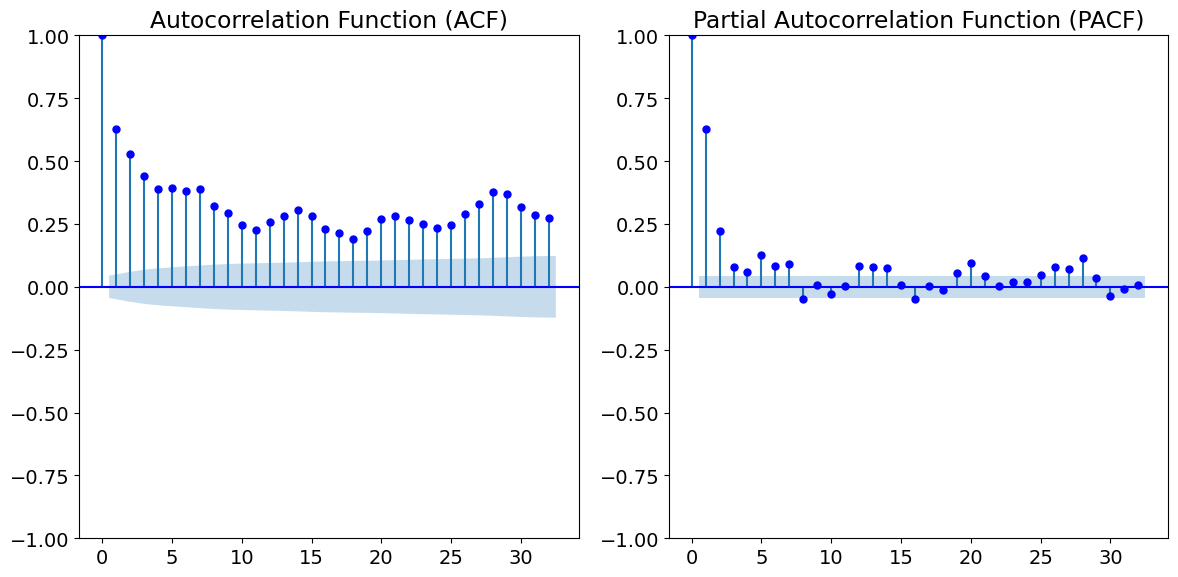

<module 'matplotlib.pyplot' from 'C:\\Users\\brend\\Desktop\\PythonVenv\\py3_13\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [8]:
from Utilities.Charting import plot_paired_autocorrelation_factors
plot_paired_autocorrelation_factors(series_df, 'sold', lags=32)

You can observe that with 32 lags, there is regular correlation throughout the series. Values extending outside the blue band (representing the 95% confidence interval) are considered statistically significant. This indicates temporal dependencies in the series, which is worth considering in model builds.

By examining the PACF, which controls for the effects of intermediate lags, we see a distinctive pattern of significant spikes occurring at regular 6-to-7-day intervals. This pattern becomes evident through the prominent spikes at lags 6, 7, 12, 13, 14, 20, and 38, exceeding the significance threshold (blue band). Obviously, this is not an exact 7-day cycle, but this is fairly common for food sales.

Residual Analysis

Intercept (b0): 32.7665774752734
Slope Coefficient (b1): -0.010712900077813897
R-squared: 0.2184485306967826


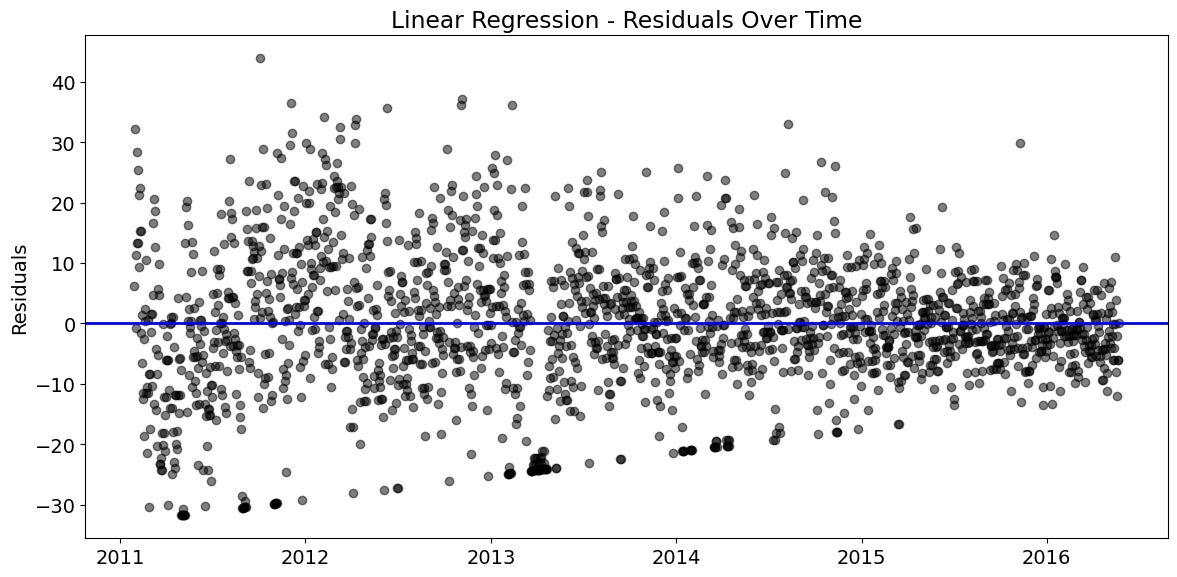

In [11]:
from Modeling.StatisticalModeling.OLS import ols_model

series_df.reset_index(inplace=True)
series_df['days'] = (pd.to_datetime(series_df['date']) -
                     pd.to_datetime(series_df['date'].min())).dt.days

model = ols_model(series_df[['days']], series_df['sold'])
X = series_df[['days']]
series_df['predicted'] = model.predict(X)
series_df['residuals'] = series_df['sold'] - series_df['predicted']

plt.figure(figsize=(12, 6))
plt.scatter(series_df['date'], series_df['residuals'], alpha=0.5, color=custom_palette[0])
plt.axhline(y=0, color=custom_palette[1], linestyle='-', linewidth=2)
plt.title('Linear Regression - Residuals Over Time')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

Train-Test Split

In [12]:
from dateutil.relativedelta import relativedelta
last_date = series_df['date'].max()
split_date = last_date - relativedelta(months=3)

# Create split point
train_df = series_df[series_df['date'] < split_date]
test_df = series_df[series_df['date'] >= split_date]

In [13]:
# Find split points
last_date = series_df['date'].max()
test_split_date = last_date - relativedelta(months=3)
val_split_date = test_split_date - relativedelta(months=3)

# Create train, validation, and test sets
train_df = series_df[series_df['date'] < val_split_date]
val_df = series_df[(series_df['date'] >= val_split_date) & (series_df['date'] <
test_split_date)]
test_df = series_df[series_df['date'] >= test_split_date]

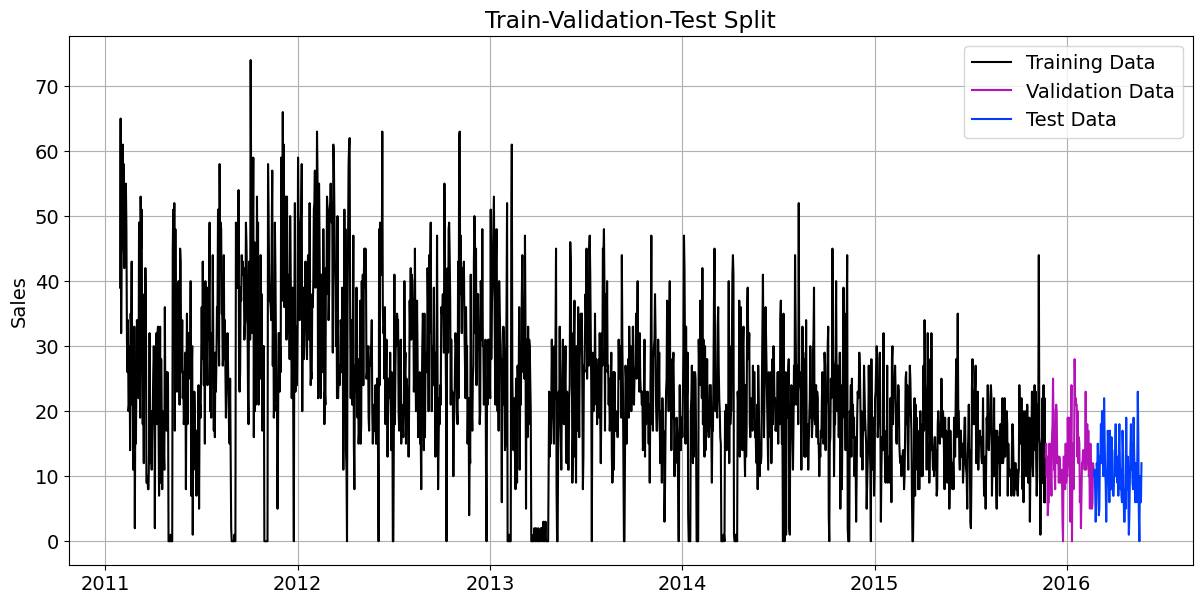

In [15]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_df['date'], train_df['sold'],
 label='Training Data', color='black')
plt.plot(val_df['date'], val_df['sold'],
 label='Validation Data', color='#b512b8')
plt.plot(test_df['date'], test_df['sold'], label='Test Data', color='#003DFD')
plt.tight_layout()
plt.title('Train-Validation-Test Split')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

Error Metrics:

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = mean_absolute_percentage_error(actual+1, np.array(forecast)+1)
    return mae, rmse, mape

def calculate_scaled_metrics(actual, forecast, training_data):
    in_sample_mae = np.mean(np.abs(np.diff(training_data)))
    if in_sample_mae == 0:
        return np.inf, np.inf
    errors = np.abs(actual - forecast)
    squared_errors = (actual - forecast) ** 2
    mase = np.mean(errors) / in_sample_mae
    rmsse = np.sqrt(np.mean(squared_errors)) / in_sample_mae
    return mase, rmsse

def calculate_relative_errors(actual, forecast, baseline_metrics):
    mae, rmse, mape = calculate_metrics(actual, forecast)
    rel_mae = (mae / baseline_metrics[0] if baseline_metrics[0] != 0 else np.inf)
    rel_rmse = (rmse / baseline_metrics[1] if baseline_metrics[1] != 0 else np.inf)
    rel_mape = (mape / baseline_metrics[2] if baseline_metrics[2] != 0 else np.inf)
    return rel_mae, rel_rmse, rel_mape